# COMP0051 Algorithmic Trading Project

In [1]:
import os
import sys
import time
from datetime import datetime, timezone
from pathlib import Path
from fredapi import Fred
import ccxt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from dotenv import load_dotenv
from pathlib import Path
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter
load_dotenv()

True

### Crypto Data Download

In [2]:
SYMBOLS    = ["BTC/USDT", "ETH/USDT", "DOGE/USDT", "ADA/USDT"]
TIMEFRAME  = "1d"
SINCE      = "2020-01-01"
UNTIL      = "2026-03-20"
DATA_DIR   = Path("data_final")
DATA_DIR.mkdir(parents=True, exist_ok=True)

exchange = ccxt.binance()
since_ms = exchange.parse8601(f"{SINCE}T00:00:00Z")
until_ms = exchange.parse8601(f"{UNTIL}T23:59:59Z")

for symbol in SYMBOLS:
    print(f"Downloading {symbol}...", end="", flush=True)

    all_bars = []
    since = since_ms

    while True:
        bars = exchange.fetch_ohlcv(symbol, timeframe=TIMEFRAME, since=since, limit=1000)
        if not bars:
            break

        bars = [bar for bar in bars if bar[0] <= until_ms]
        if not bars:
            break

        all_bars.extend(bars)
        since = bars[-1][0] + 1
        print(".", end="", flush=True)
        time.sleep(0.3)

        if bars[-1][0] >= until_ms:
            break

    df = pd.DataFrame(
        all_bars,
        columns=["timestamp", "open", "high", "low", "close", "volume"],
    )
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    df = df.set_index("timestamp").sort_index()

    fname = DATA_DIR / f"{symbol.replace('/', '')}_{TIMEFRAME}.parquet"
    df.to_parquet(fname, engine="pyarrow")
    print(f" {len(df):,} bars -> {fname}")

print("Done.")

Done.


### Macro Data - Effective Fed Funds Rate (FRED)

In [3]:
fred = Fred(api_key=os.environ["FRED_API_KEY"])

dff = fred.get_series("DFF", observation_start=SINCE, observation_end=UNTIL)
dff = dff.rename("fed_funds_rate").rename_axis("date")
dff.index = pd.to_datetime(dff.index, utc=True)

dff_path = DATA_DIR / "DFF_daily.parquet"
dff.to_frame().to_parquet(dff_path, engine="pyarrow")
print(f"Fed Funds Rate: {len(dff):,} observations → {dff_path}")
dff.tail()

Fed Funds Rate: 2,271 observations → data_final/DFF_daily.parquet


date
2026-03-16 00:00:00+00:00    3.64
2026-03-17 00:00:00+00:00    3.64
2026-03-18 00:00:00+00:00    3.64
2026-03-19 00:00:00+00:00    3.64
2026-03-20 00:00:00+00:00    3.64
Name: fed_funds_rate, dtype: float64

### Data Quality Checks & Cleaning

In [4]:
VALUE_COLUMNS = ["open", "high", "low", "close", "volume"]
PANDAS_FREQ = str(TIMEFRAME).upper()


def clean_ohlcv(df: pd.DataFrame) -> pd.DataFrame:
    frame = df.sort_index().copy()
    frame = frame[~frame.index.duplicated(keep="first")]

    for col in VALUE_COLUMNS:
        frame[col] = pd.to_numeric(frame[col], errors="coerce")

    valid = (
        frame[VALUE_COLUMNS].notna().all(axis=1)
        & (frame[["open", "high", "low", "close"]] > 0).all(axis=1)
        & (frame["volume"] >= 0)
        & (frame["high"] >= frame["low"])
        & (frame["high"] >= frame[["open", "close"]].max(axis=1))
        & (frame["low"] <= frame[["open", "close"]].min(axis=1))
    )
    frame = frame.loc[valid].copy()

    r = frame["close"].pct_change()
    z = (r - r.rolling(30, min_periods=10).mean()) / r.rolling(30, min_periods=10).std(ddof=0).replace(0.0, np.nan)
    frame["simple_return"] = r
    frame["return_zscore"] = z
    frame["is_outlier"] = z.abs().gt(5.0).fillna(False)
    return frame


def quick_audit(df: pd.DataFrame, symbol: str, stage: str) -> dict:
    idx = pd.DatetimeIndex(df.index)
    expected = pd.date_range(idx.min(), idx.max(), freq=PANDAS_FREQ, tz="UTC")
    return {
        "symbol": symbol,
        "stage": stage,
        "rows": len(df),
        "duplicates": int(idx.duplicated().sum()),
        "missing_bars": int(len(expected.difference(idx))),
        "null_rows": int(df[VALUE_COLUMNS].isna().any(axis=1).sum()),
        "outliers": int(df["is_outlier"].sum()) if "is_outlier" in df else 0,
    }


cleaned_frames = {}
audit_rows = []

for symbol in SYMBOLS:
    key = symbol.replace("/", "")
    raw_path = DATA_DIR / f"{key}_{TIMEFRAME}.parquet"

    raw = pd.read_parquet(raw_path)
    raw.index = pd.to_datetime(raw.index, utc=True)
    clean = clean_ohlcv(raw)

    clean_path = DATA_DIR / f"{key}_{TIMEFRAME}_cleaned.parquet"
    clean.to_parquet(clean_path, engine="pyarrow")

    cleaned_frames[symbol] = clean
    audit_rows.append(quick_audit(raw, symbol, "raw"))
    audit_rows.append(quick_audit(clean, symbol, "cleaned"))

quality_report = pd.DataFrame(audit_rows).sort_values(["symbol", "stage"]).reset_index(drop=True)
quality_report

,symbol,stage,rows,duplicates,missing_bars,null_rows,outliers
0,ADA/USDT,cleaned,2271,0,0,0,1
1,ADA/USDT,raw,2271,0,0,0,0
2,BTC/USDT,cleaned,2271,0,0,0,0
3,BTC/USDT,raw,2271,0,0,0,0
4,DOGE/USDT,cleaned,2271,0,0,0,1
5,DOGE/USDT,raw,2271,0,0,0,0
6,ETH/USDT,cleaned,2271,0,0,0,0
7,ETH/USDT,raw,2271,0,0,0,0


##### Cleaning Results

- **No structural data issues were found** in either stage: all symbols have `duplicates = 0`, `missing_bars = 0`, and `null_rows = 0`.
- **Row counts are unchanged** (`2271` raw and `2271` cleaned), so no rows were dropped by the current cleaning rules.
- For this run, **1 outlier was flagged in `ADA/USDT` and `DOGE/USDT`**, and none in `BTC/USDT` or `ETH/USDT`.

> Note: Outliers are **flagged, not removed**.

### Excess Returns Series

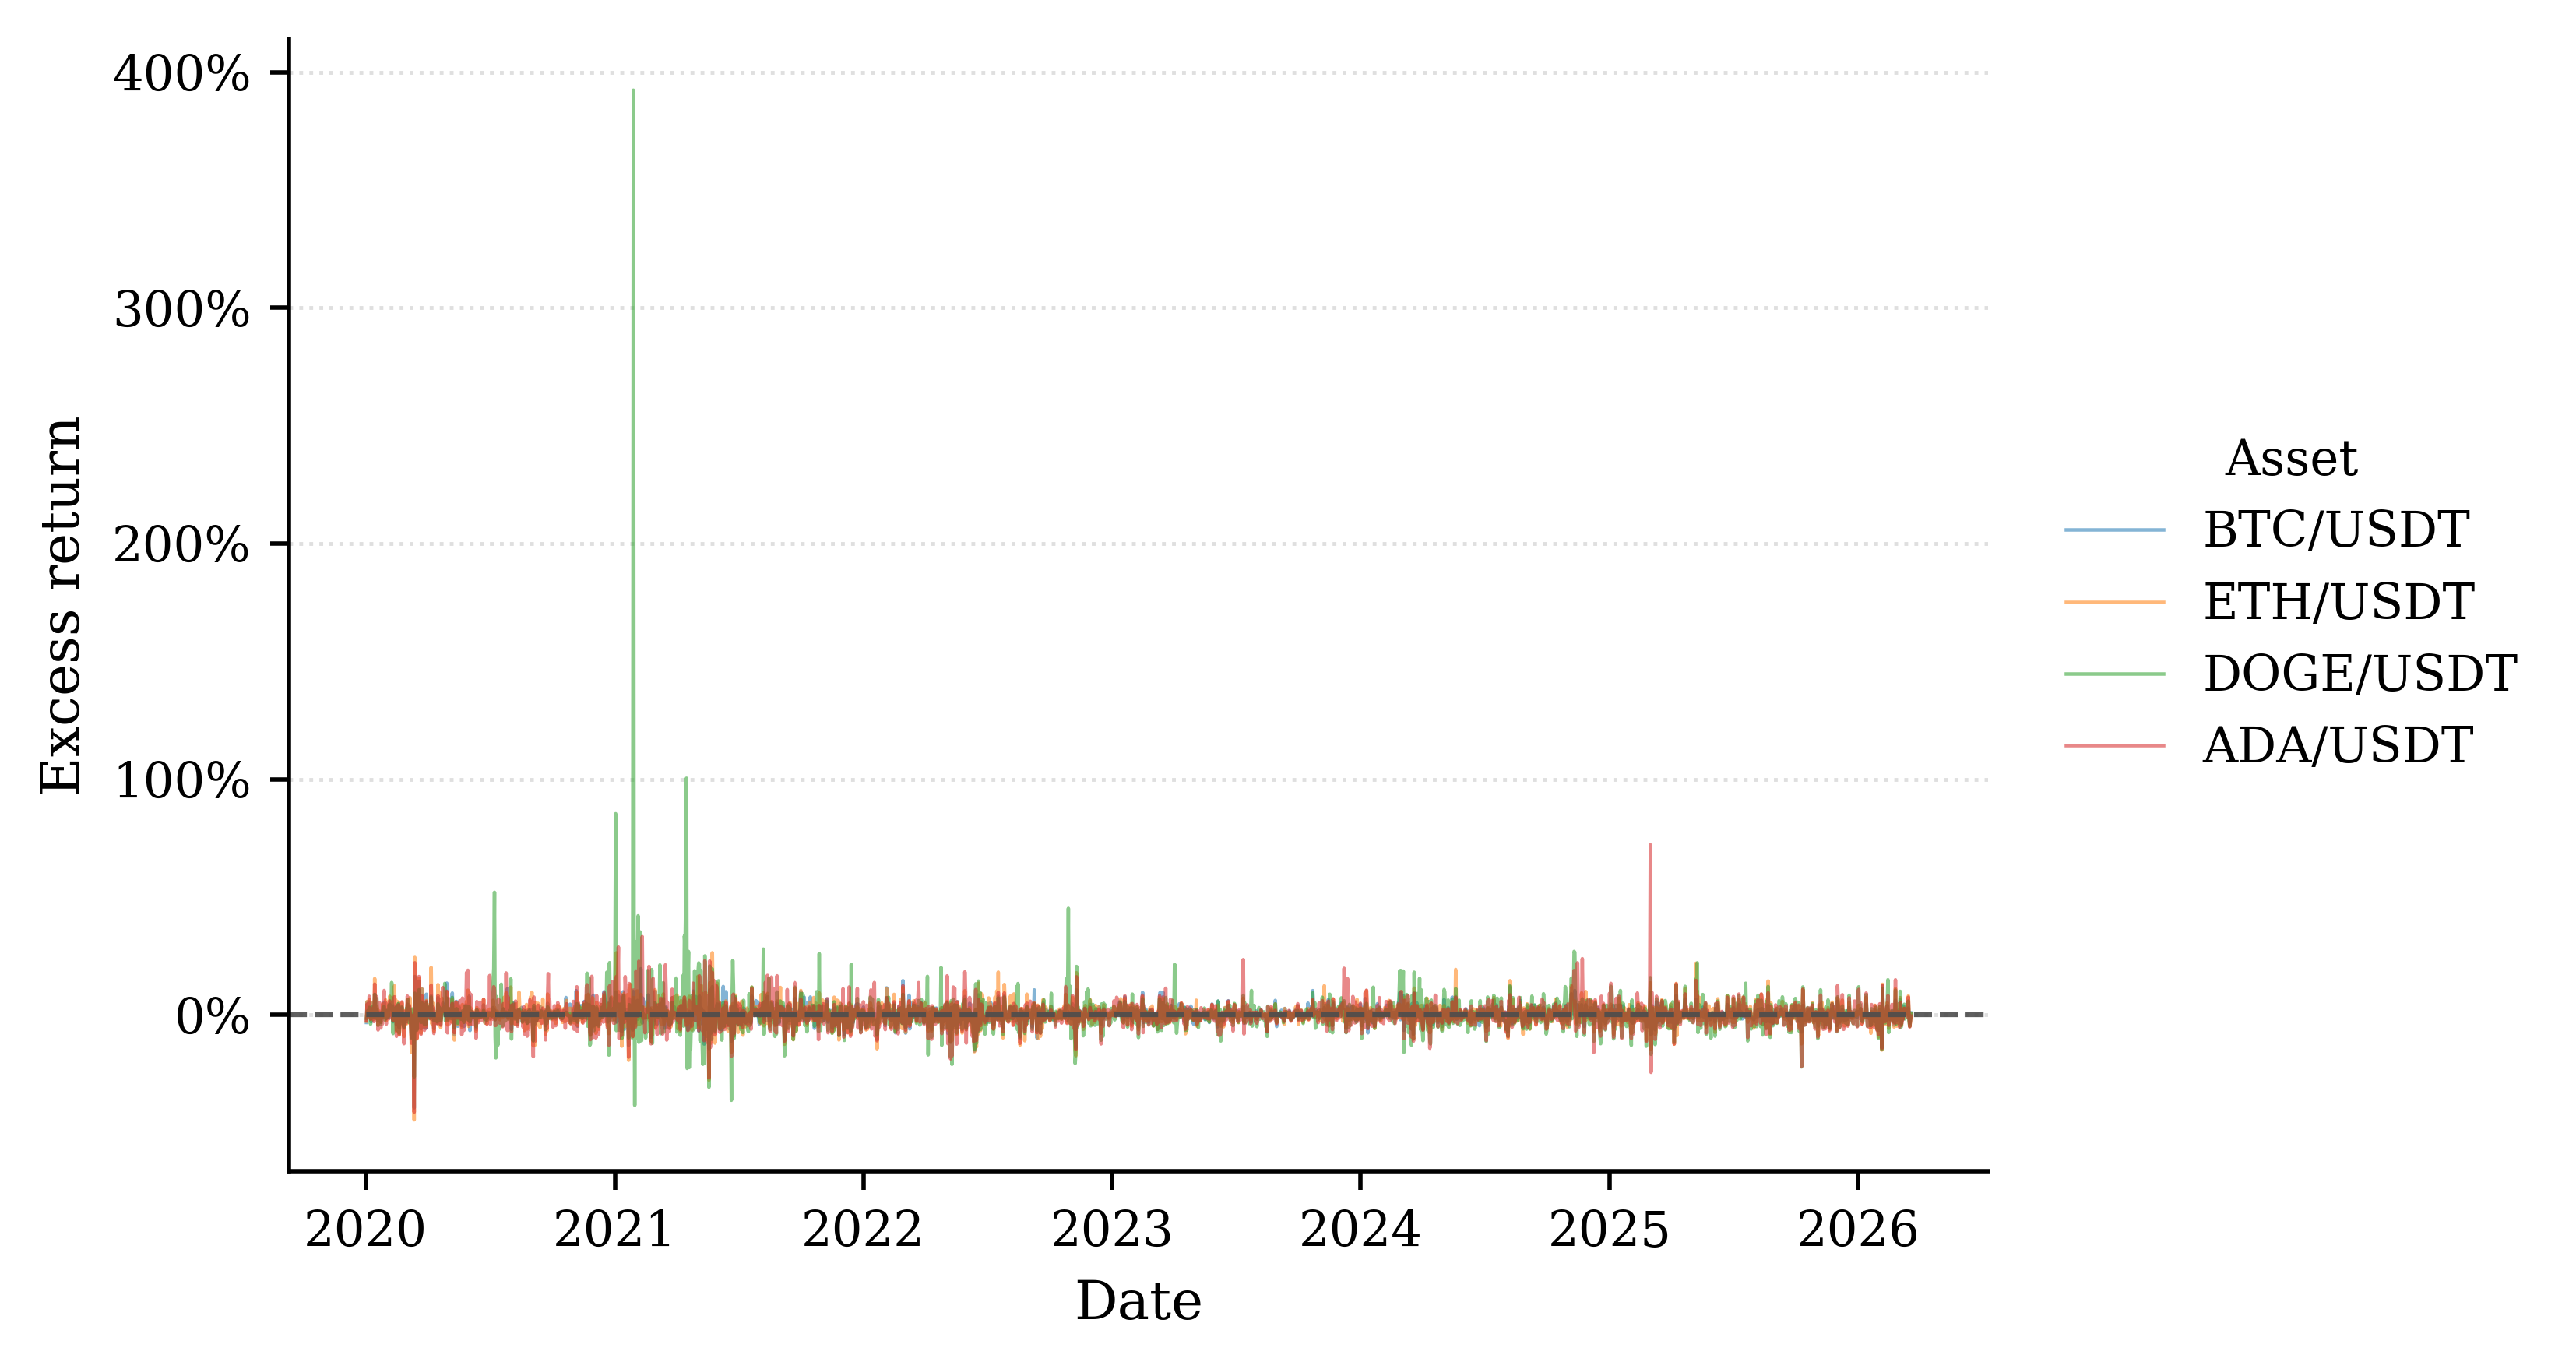

,mean,std,min,max
BTC/USDT,0.001464,0.032319,-0.395078,0.195359
ETH/USDT,0.002113,0.043330,-0.445999,0.263327
DOGE/USDT,0.004596,0.105249,-0.384395,3.924112
ADA/USDT,0.002232,0.053569,-0.413232,0.721407


In [5]:
# Convert FRED DFF (annual %, simple) to an approximate daily return.
rf_daily = ((1 + dff / 100.0) ** (1 / 365.0) - 1).rename("rf_daily")
rf_daily = rf_daily.reindex(pd.date_range(dff.index.min(), dff.index.max(), freq="D", tz="UTC")).ffill()

excess_returns = {}
for symbol in SYMBOLS:
    asset = cleaned_frames[symbol].copy()
    asset_return = asset["close"].pct_change().rename("asset_return")
    aligned_rf = rf_daily.reindex(asset.index).ffill().rename("rf_daily")

    asset["rf_daily"] = aligned_rf
    asset["excess_return"] = asset_return - aligned_rf
    cleaned_frames[symbol] = asset

    excess_returns[symbol] = asset["excess_return"].rename(symbol)

excess_returns_df = pd.concat(excess_returns.values(), axis=1).dropna(how="all")
excess_returns_df.head()

plt.rcParams.update({
    "figure.dpi": 500,
    "savefig.dpi": 500,
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

colors = plt.get_cmap("tab10").colors

fig, ax = plt.subplots(figsize=(6.5, 3.4), constrained_layout=True)

for i, col in enumerate(excess_returns_df.columns):
    c = colors[i % len(colors)]
    ax.plot(
        excess_returns_df.index,
        excess_returns_df[col],
        color=c,
        linewidth=0.65,
        alpha=0.55,
        label=col,
    )

ax.axhline(0.0, color="0.3", linewidth=0.9, linestyle="--", alpha=0.9)
ax.set_xlabel("Date")
ax.set_ylabel("Excess return")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(True, axis="y", linestyle=":", linewidth=0.7, alpha=0.4)
ax.grid(False, axis="x")

ax.legend(title="Asset", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

out_dir = Path("output")
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / "daily_excess_returns.pdf", bbox_inches="tight")
fig.savefig(out_dir / "daily_excess_returns.png", bbox_inches="tight")

plt.show()

excess_returns_df.describe().T[["mean", "std", "min", "max"]]


### Common asset panel

Single datetime index with **MultiIndex** columns `(field, asset)`: `close` and `excess_return` for each symbol. Rows are aligned across assets; `dropna(how="any")` keeps only dates where every column is defined (drops the initial `pct_change` row with no excess return).

In [6]:
close_wide = pd.concat(
    [cleaned_frames[s]["close"] for s in SYMBOLS],
    axis=1,
    keys=pd.MultiIndex.from_product([["close"], SYMBOLS], names=["field", "asset"]),
)
excess_wide = pd.concat(
    [cleaned_frames[s]["excess_return"] for s in SYMBOLS],
    axis=1,
    keys=pd.MultiIndex.from_product([["excess_return"], SYMBOLS], names=["field", "asset"]),
)
asset_panel = pd.concat([close_wide, excess_wide], axis=1).sort_index(axis=1)
# Intersection of valid dates: all assets have close and excess_return
asset_panel = asset_panel.dropna(how="any")

asset_panel.head()

field                        close                             excess_return  \
asset                     ADA/USDT BTC/USDT DOGE/USDT ETH/USDT      ADA/USDT   
timestamp                                                                      
2020-01-02 00:00:00+00:00  0.03269  6965.71  0.001995   127.19     -0.023638   
2020-01-03 00:00:00+00:00  0.03417  7344.96  0.002024   134.35      0.045232   
2020-01-04 00:00:00+00:00  0.03434  7354.11  0.002058   134.20      0.004933   
2020-01-05 00:00:00+00:00  0.03460  7358.75  0.002070   135.37      0.007529   
2020-01-06 00:00:00+00:00  0.03732  7758.00  0.002134   144.15      0.078571   

field                                                    
asset                      BTC/USDT DOGE/USDT  ETH/USDT  
timestamp                                                
2020-01-02 00:00:00+00:00 -0.032697 -0.014564 -0.027418  
2020-01-03 00:00:00+00:00  0.054403  0.014243  0.056252  
2020-01-04 00:00:00+00:00  0.001204  0.016908 -0.001159  
2020-01-05 00:00:00+00:00  0.000589  0.005643  0.008676  
2020-01-06 00:00:00+00:00  0.054213  0.031268  0.064817

### Walk-forward validation split and backtest framework

- **Outer holdout:** last `HOLDOUT_FRAC` of the sample (final test; not used in walk-forward).
- **Walk-forward:** only on the **development** slice; `WF_MODE` is `expanding` (train from dev start) or `rolling` (fixed `TRAIN_BARS` before each validation block).

In [7]:
# --- Outer holdout (20–25% tail) + walk-forward on development sample ---
idx = asset_panel.index.sort_values()
n = len(idx)

HOLDOUT_FRAC = 0.225  # e.g. 0.20–0.25; reserved final test period
holdout_n = max(1, int(round(HOLDOUT_FRAC * n)))
holdout_index = idx[-holdout_n:]
dev_index = idx[:-holdout_n]

# --- Walk-forward config (bars = trading days for 1d data) ---
INITIAL_TRAIN_BARS = 756  # ~3y business days before first validation (tune as needed)
VAL_BARS = 126  # ~6 months per validation block
STEP_BARS = 126  # non-overlapping validation windows
WF_MODE = "expanding"  # "expanding" | "rolling"
TRAIN_BARS = 756  # rolling mode only: fixed training window length

n_dev = len(dev_index)
if INITIAL_TRAIN_BARS + VAL_BARS > n_dev:
    raise ValueError(
        f"Development sample too short for one fold: n_dev={n_dev}, "
        f"need INITIAL_TRAIN_BARS + VAL_BARS = {INITIAL_TRAIN_BARS + VAL_BARS}"
    )
if WF_MODE not in ("expanding", "rolling"):
    raise ValueError('WF_MODE must be "expanding" or "rolling"')
if WF_MODE == "rolling" and TRAIN_BARS > INITIAL_TRAIN_BARS:
    raise ValueError("For rolling folds, set TRAIN_BARS <= INITIAL_TRAIN_BARS so fold 1 has enough history")

fold_rows = []
val_start_pos = INITIAL_TRAIN_BARS
fold_id = 0
while val_start_pos + VAL_BARS <= n_dev:
    fold_id += 1
    val_ix = dev_index[val_start_pos : val_start_pos + VAL_BARS]
    if WF_MODE == "expanding":
        train_ix = dev_index[:val_start_pos]
    else:
        t0 = val_start_pos - TRAIN_BARS
        train_ix = dev_index[t0:val_start_pos]

    fold_rows.append(
        {
            "fold": fold_id,
            "train_start": train_ix.min(),
            "train_end": train_ix.max(),
            "train_bars": len(train_ix),
            "val_start": val_ix.min(),
            "val_end": val_ix.max(),
            "val_bars": len(val_ix),
        }
    )
    val_start_pos += STEP_BARS

wf_folds = pd.DataFrame(fold_rows)
if wf_folds.empty:
    raise ValueError("No walk-forward folds generated; relax INITIAL_TRAIN_BARS, VAL_BARS, or HOLDOUT_FRAC")

# --- Printed date ranges ---
print(f"Full sample: {idx.min().date()} → {idx.max().date()} (n={n})")
print()
print(
    f"Development (train/CV): {dev_index.min().date()} → {dev_index.max().date()} "
    f"(n={len(dev_index)})"
)
print(
    f"Holdout (final test):     {holdout_index.min().date()} → {holdout_index.max().date()} "
    f"(n={len(holdout_index)}, HOLDOUT_FRAC={HOLDOUT_FRAC})"
)
print()
print(f"Walk-forward: WF_MODE={WF_MODE!r}, INITIAL_TRAIN_BARS={INITIAL_TRAIN_BARS}, "
      f"VAL_BARS={VAL_BARS}, STEP_BARS={STEP_BARS}" + (f", TRAIN_BARS={TRAIN_BARS}" if WF_MODE == "rolling" else ""))
print()
display(wf_folds)
print()
assert dev_index.max() < holdout_index.min(), "dev and holdout ranges should not overlap"
print("Sanity check: dev_index.max() < holdout_index.min() — OK")

Full sample: 2020-01-02 → 2026-03-20 (n=2270)

Development (train/CV): 2020-01-02 → 2024-10-25 (n=1759)
Holdout (final test):     2024-10-26 → 2026-03-20 (n=511, HOLDOUT_FRAC=0.225)

Walk-forward: WF_MODE='expanding', INITIAL_TRAIN_BARS=756, VAL_BARS=126, STEP_BARS=126



,fold,train_start,train_end,train_bars,val_start,val_end,val_bars
0,1,2020-01-02 00:00:00+00:00,2022-01-26 00:00:00+00:00,756,2022-01-27 00:00:00+00:00,2022-06-01 00:00:00+00:00,126
1,2,2020-01-02 00:00:00+00:00,2022-06-01 00:00:00+00:00,882,2022-06-02 00:00:00+00:00,2022-10-05 00:00:00+00:00,126
2,3,2020-01-02 00:00:00+00:00,2022-10-05 00:00:00+00:00,1008,2022-10-06 00:00:00+00:00,2023-02-08 00:00:00+00:00,126
3,4,2020-01-02 00:00:00+00:00,2023-02-08 00:00:00+00:00,1134,2023-02-09 00:00:00+00:00,2023-06-14 00:00:00+00:00,126
4,5,2020-01-02 00:00:00+00:00,2023-06-14 00:00:00+00:00,1260,2023-06-15 00:00:00+00:00,2023-10-18 00:00:00+00:00,126
5,6,2020-01-02 00:00:00+00:00,2023-10-18 00:00:00+00:00,1386,2023-10-19 00:00:00+00:00,2024-02-21 00:00:00+00:00,126
6,7,2020-01-02 00:00:00+00:00,2024-02-21 00:00:00+00:00,1512,2024-02-22 00:00:00+00:00,2024-06-26 00:00:00+00:00,126



Sanity check: dev_index.max() < holdout_index.min() — OK


### Strategy 1 – Trend signal construction

Baseline **trend** proxy: distance of spot from a **50-day moving average** of close (`trend_raw = close / ma_50 - 1`). Fifty trading days is a slow trend filter; a longer MA (e.g. 100-day) can be added later.

**Volatility scaling:** divide `trend_raw` by a **20-day rolling** standard deviation of **daily simple returns** (`pct_change` on close), matching the excess-return definition elsewhere. That puts the signal on a comparable scale across assets and reduces the influence of quiet versus volatile regimes.

**Clipping:** `signal_strength` is clipped to ±`SIGNAL_CLIP` so a single extreme day does not create absurd leverage pressure.

**Dead zone:** positions are **discrete** ({-1, 0, +1}): long if clipped `signal_strength > DEAD_ZONE`, short if `< -DEAD_ZONE`, else flat. This avoids trading tiny noisy signals.

**Parameters** (`MA_WINDOW`, `VOL_WINDOW`, `DEAD_ZONE`, `SIGNAL_CLIP`) are initial choices and can be tuned in walk-forward validation (see the previous section).

Outputs are stored in `signal_panel` with the same MultiIndex column layout as `asset_panel` (`field` × `asset`), aligned to `asset_panel.index`.

In [8]:
# --- Trend signal parameters (initial values; tune in walk-forward) ---
MA_WINDOW = 50
VOL_WINDOW = 20
DEAD_ZONE = 0.25  # on vol-normalised, clipped signal_strength
SIGNAL_CLIP = 5.0

close_px = asset_panel["close"]

ma50_list, trend_raw_list, vol_20_list, signal_strength_list, trend_position_list = [], [], [], [], []

for s in SYMBOLS:
    c = close_px[s]
    ma_50 = c.rolling(MA_WINDOW, min_periods=MA_WINDOW).mean()
    trend_raw = c / ma_50 - 1
    ret = c.pct_change()
    vol_20 = ret.rolling(VOL_WINDOW, min_periods=VOL_WINDOW).std(ddof=0).replace(0.0, np.nan)
    signal_strength = (trend_raw / vol_20).clip(-SIGNAL_CLIP, SIGNAL_CLIP)

    tp = np.where(signal_strength > DEAD_ZONE, 1.0, np.where(signal_strength < -DEAD_ZONE, -1.0, 0.0))
    trend_position = pd.Series(tp, index=c.index, dtype=float).where(signal_strength.notna(), np.nan)

    ma50_list.append(ma_50.rename(s))
    trend_raw_list.append(trend_raw.rename(s))
    vol_20_list.append(vol_20.rename(s))
    signal_strength_list.append(signal_strength.rename(s))
    trend_position_list.append(trend_position.rename(s))

mi = pd.MultiIndex.from_product


def _field_wide(field: str, parts: list[pd.Series]) -> pd.DataFrame:
    return pd.concat(parts, axis=1, keys=mi([[field], SYMBOLS], names=["field", "asset"]))


ma_50_wide = _field_wide("ma_50", ma50_list)
trend_raw_wide = _field_wide("trend_raw", trend_raw_list)
vol_20_wide = _field_wide("vol_20", vol_20_list)
signal_strength_wide = _field_wide("signal_strength", signal_strength_list)
trend_position_wide = _field_wide("trend_position", trend_position_list)

signal_panel = pd.concat(
    [ma_50_wide, trend_raw_wide, vol_20_wide, signal_strength_wide, trend_position_wide],
    axis=1,
).sort_index(axis=1)

assert signal_panel.index.equals(asset_panel.index)

signal_panel.head()

field                        ma_50                              \
asset                     ADA/USDT BTC/USDT DOGE/USDT ETH/USDT   
timestamp                                                        
2020-01-02 00:00:00+00:00      NaN      NaN       NaN      NaN   
2020-01-03 00:00:00+00:00      NaN      NaN       NaN      NaN   
2020-01-04 00:00:00+00:00      NaN      NaN       NaN      NaN   
2020-01-05 00:00:00+00:00      NaN      NaN       NaN      NaN   
2020-01-06 00:00:00+00:00      NaN      NaN       NaN      NaN   

field                     signal_strength                              \
asset                            ADA/USDT BTC/USDT DOGE/USDT ETH/USDT   
timestamp                                                               
2020-01-02 00:00:00+00:00             NaN      NaN       NaN      NaN   
2020-01-03 00:00:00+00:00             NaN      NaN       NaN      NaN   
2020-01-04 00:00:00+00:00             NaN      NaN       NaN      NaN   
2020-01-05 00:00:00+00:00             NaN      NaN       NaN      NaN   
2020-01-06 00:00:00+00:00             NaN      NaN       NaN      NaN   

field                     trend_position                              \
asset                           ADA/USDT BTC/USDT DOGE/USDT ETH/USDT   
timestamp                                                              
2020-01-02 00:00:00+00:00            NaN      NaN       NaN      NaN   
2020-01-03 00:00:00+00:00            NaN      NaN       NaN      NaN   
2020-01-04 00:00:00+00:00            NaN      NaN       NaN      NaN   
2020-01-05 00:00:00+00:00            NaN      NaN       NaN      NaN   
2020-01-06 00:00:00+00:00            NaN      NaN       NaN      NaN   

field                     trend_raw                               vol_20  \
asset                      ADA/USDT BTC/USDT DOGE/USDT ETH/USDT ADA/USDT   
timestamp                                                                  
2020-01-02 00:00:00+00:00       NaN      NaN       NaN      NaN      NaN   
2020-01-03 00:00:00+00:00       NaN      NaN       NaN      NaN      NaN   
2020-01-04 00:00:00+00:00       NaN      NaN       NaN      NaN      NaN   
2020-01-05 00:00:00+00:00       NaN      NaN       NaN      NaN      NaN   
2020-01-06 00:00:00+00:00       NaN      NaN       NaN      NaN      NaN   

field                                                  
asset                     BTC/USDT DOGE/USDT ETH/USDT  
timestamp                                              
2020-01-02 00:00:00+00:00      NaN       NaN      NaN  
2020-01-03 00:00:00+00:00      NaN       NaN      NaN  
2020-01-04 00:00:00+00:00      NaN       NaN      NaN  
2020-01-05 00:00:00+00:00      NaN       NaN      NaN  
2020-01-06 00:00:00+00:00      NaN       NaN      NaN

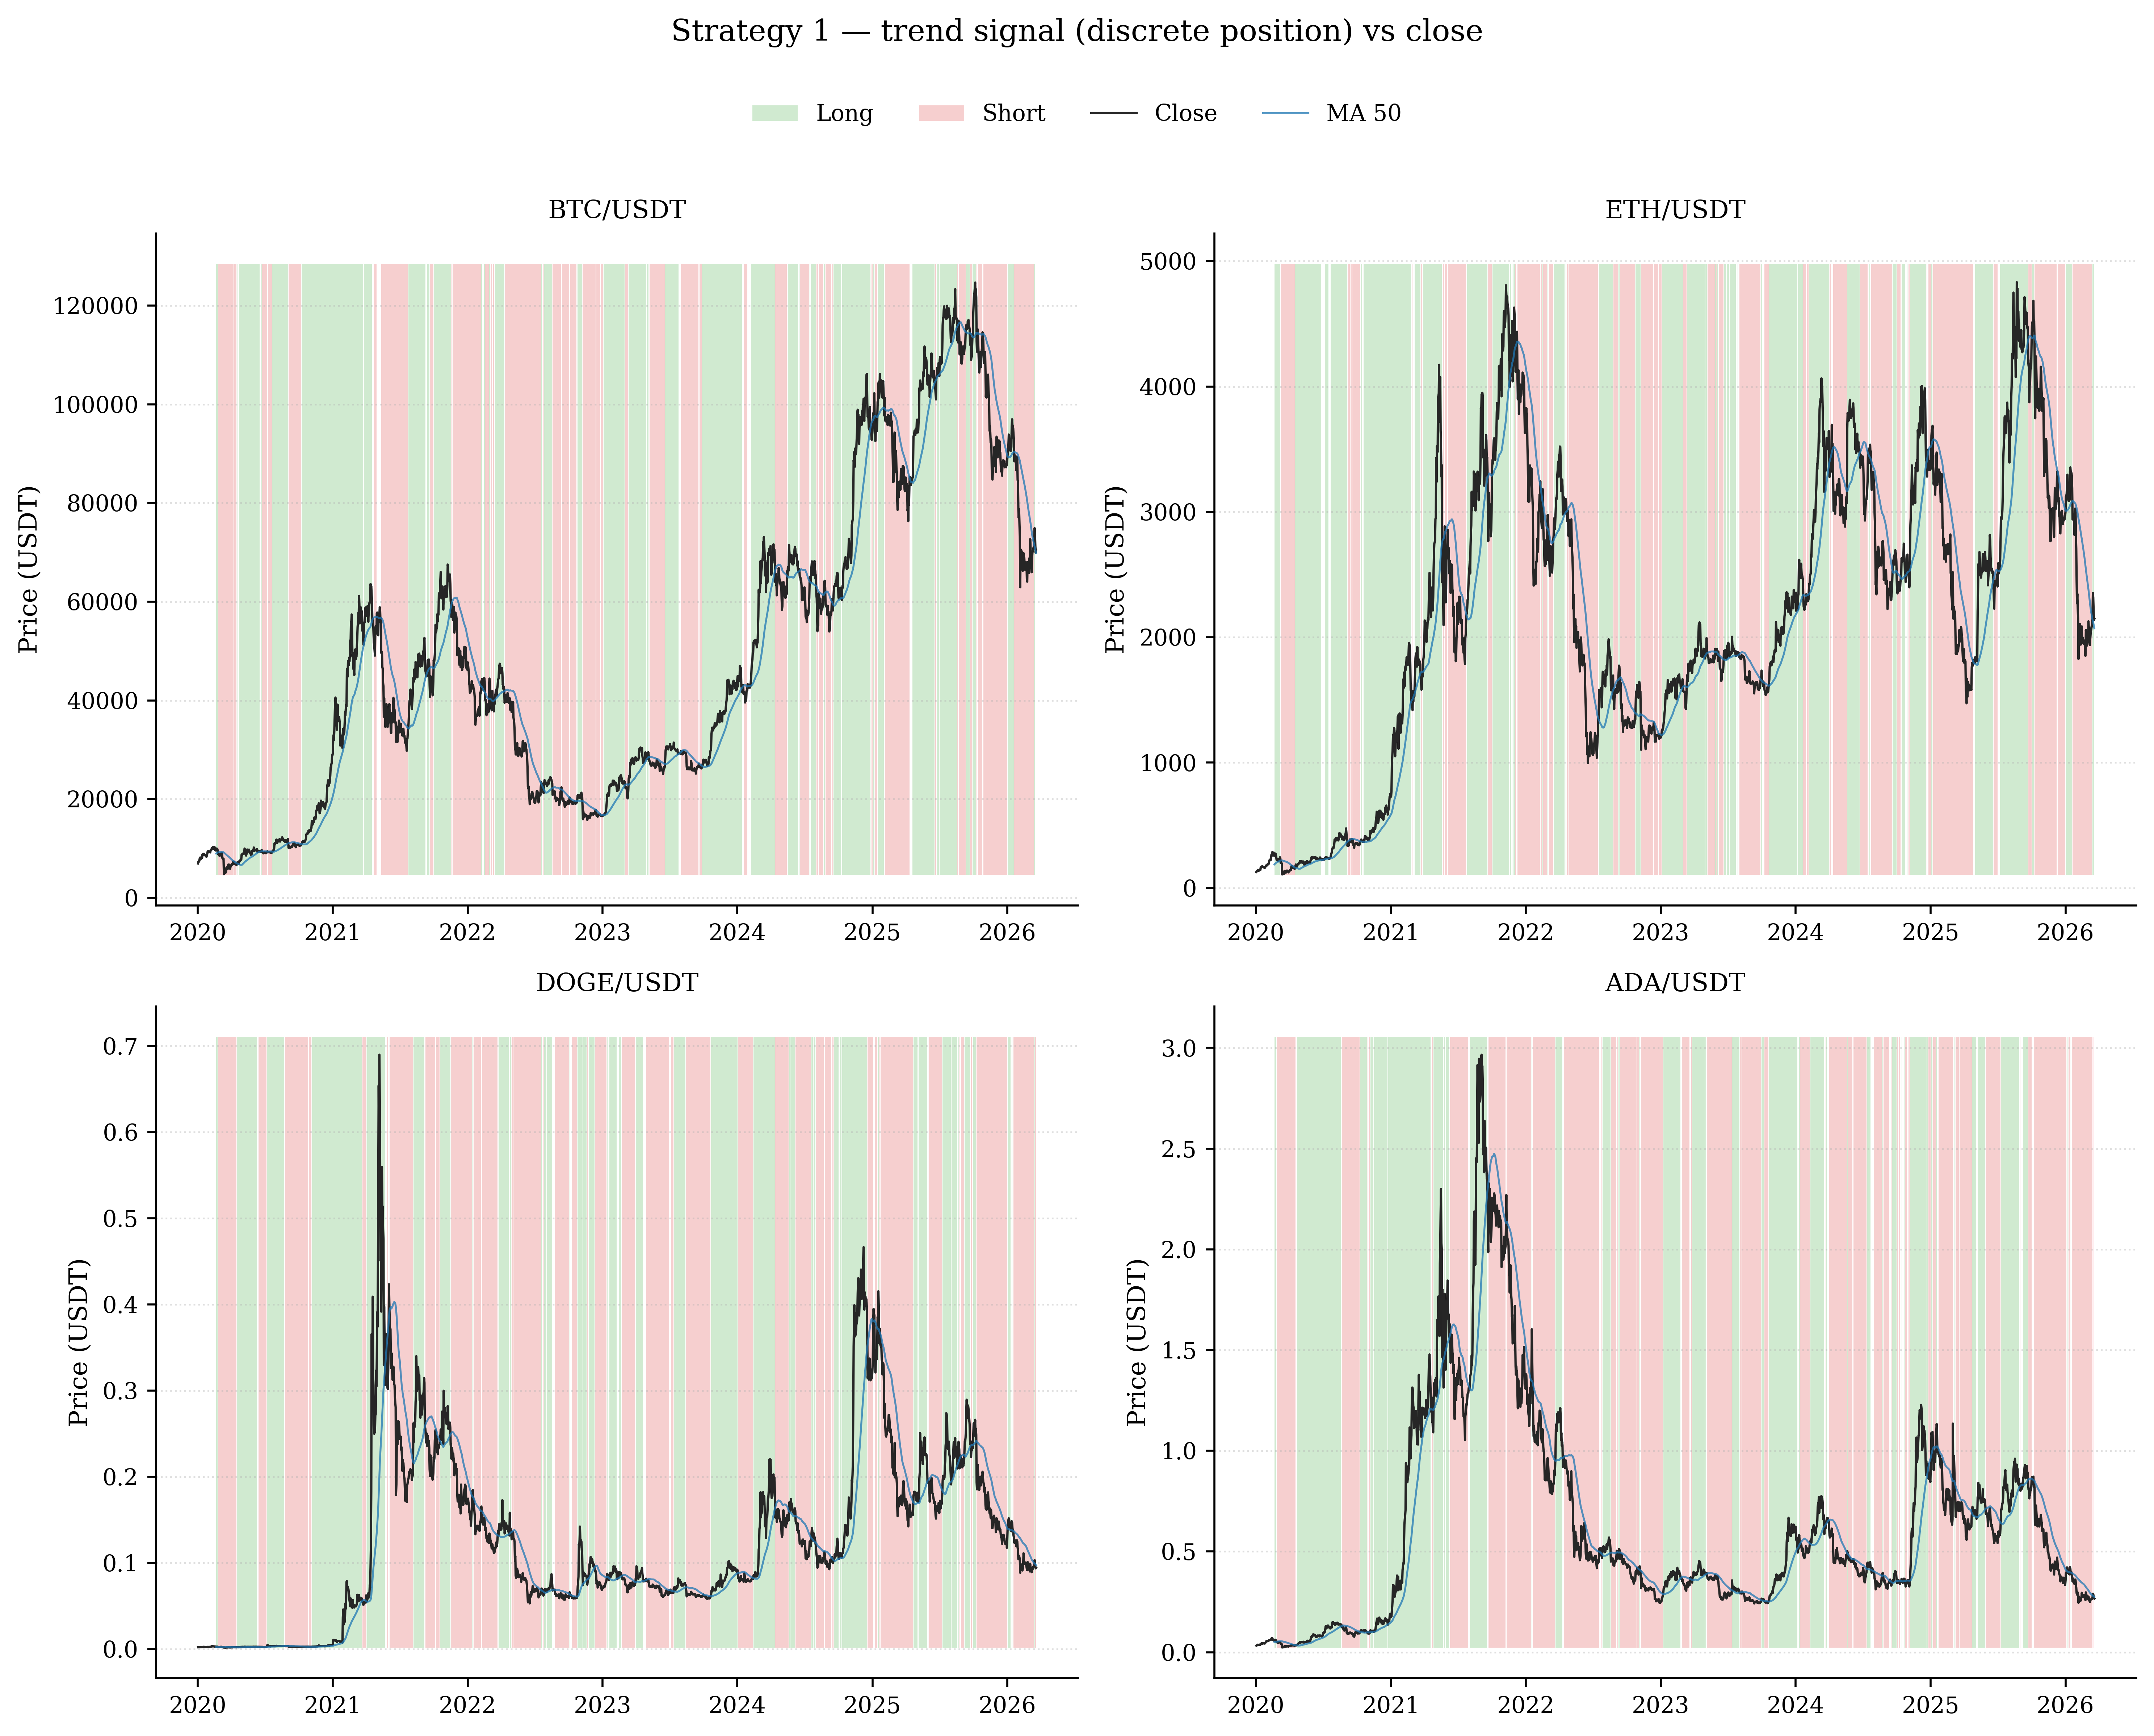

In [9]:
# Price with trend position overlay (green = long, red = short, unshaded = flat)
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=False)
axes = axes.ravel()

for ax, s in zip(axes, SYMBOLS):
    close = close_px[s]
    ma_50 = signal_panel["ma_50"][s]
    pos = signal_panel["trend_position"][s]

    idx = close.index
    y_lo = float(close.min()) * 0.97
    y_hi = float(close.max()) * 1.03

    p = pos.to_numpy(dtype=float)
    long_m = np.isfinite(p) & (p == 1.0)
    short_m = np.isfinite(p) & (p == -1.0)

    ax.fill_between(idx, y_lo, y_hi, where=long_m, color="#2ca02c", alpha=0.22, linewidth=0, label="Long")
    ax.fill_between(idx, y_lo, y_hi, where=short_m, color="#d62728", alpha=0.22, linewidth=0, label="Short")
    ax.plot(idx, close, color="0.15", linewidth=0.9, label="Close")
    ax.plot(idx, ma_50, color="tab:blue", linewidth=0.75, alpha=0.75, label="MA 50")

    ax.set_title(s)
    ax.set_ylabel("Price (USDT)")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, axis="y", linestyle=":", linewidth=0.7, alpha=0.4)

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)
fig.suptitle("Strategy 1 — trend signal (discrete position) vs close", y=1.06)
plt.tight_layout()

out_dir = Path("output")
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / "trend_signals_vs_price.png", bbox_inches="tight", dpi=150)
fig.savefig(out_dir / "trend_signals_vs_price.pdf", bbox_inches="tight")
plt.show()

### Strategy 1 – Position sizing and exposure mapping

This step turns the **signal** into **tradable dollar exposures** \(\theta_{i,t}\).

**Raw score:** when `trend_position` is flat (0), weight is zero; otherwise the **conviction** is `signal_strength` (signed).

**Inverse-volatility:** scale by the existing rolling `vol_20` so high-vol names do not dominate portfolio risk.

**Normalisation:** divide risk-adjusted scores by the **cross-sectional L1 norm** \(\sum_j |w^{risk}_{j,t}|\) so weights sum to one in gross terms each day (up to all-flat days).

**Gross budget:** fixed **\(G_t = 100{,}000\)**; \(\theta_{i,t} = G_t \tilde{w}_{i,t}\), so \(\sum_i |\theta_{i,t}| = G_t\) whenever at least one asset is active (and \(0\) when all are flat).

**Costs:** transaction costs and P&L enter in a later backtest section; this cell only builds the exposure panel.

Outputs: `exposure_panel` with MultiIndex columns `(field, asset)` for `w_raw`, `w_risk`, `w_tilde`, and `theta`.

In [10]:
# --- Exposures: raw score → inverse-vol → L1 weights → dollar theta ---
GROSS_CAP = 100_000.0  # fixed gross notional budget; sum_i |theta_i| = GROSS_CAP when active

ss = signal_panel["signal_strength"]
pos = signal_panel["trend_position"]
vol = signal_panel["vol_20"]

active = (pos != 0) & pos.notna()
w_raw = ss.where(active, 0.0)

sigma = vol.replace(0.0, np.nan)
w_risk = w_raw / sigma

denom = w_risk.abs().sum(axis=1)
denom_safe = denom.replace(0.0, np.nan)
w_tilde = w_risk.div(denom_safe, axis=0).fillna(0.0)

theta = GROSS_CAP * w_tilde


def _field_wide_df(field: str, df: pd.DataFrame) -> pd.DataFrame:
    return pd.concat(
        [df[s] for s in SYMBOLS],
        axis=1,
        keys=pd.MultiIndex.from_product([[field], SYMBOLS], names=["field", "asset"]),
    )


exposure_panel = pd.concat(
    [
        _field_wide_df("w_raw", w_raw),
        _field_wide_df("w_risk", w_risk),
        _field_wide_df("w_tilde", w_tilde),
        _field_wide_df("theta", theta),
    ],
    axis=1,
).sort_index(axis=1)

assert exposure_panel.index.equals(asset_panel.index)

gross_abs = exposure_panel["theta"].abs().sum(axis=1)
active_rows = denom > 0
print(
    f"Gross |theta| sum: min={gross_abs.min():,.2f}, max={gross_abs.max():,.2f}, "
    f"mean={gross_abs.mean():,.2f}"
)
print(
    f"  (on active rows where denom>0: min={gross_abs[active_rows].min():,.2f}, "
    f"max={gross_abs[active_rows].max():,.2f}, matches GROSS_CAP={GROSS_CAP:,.0f})"
)

exposure_panel.tail()

Gross |theta| sum: min=0.00, max=100,000.00, mean=97,841.41
  (on active rows where denom>0: min=100,000.00, max=100,000.00, matches GROSS_CAP=100,000)


field                             theta                              \
asset                          ADA/USDT      BTC/USDT     DOGE/USDT   
timestamp                                                             
2026-03-16 00:00:00+00:00  10498.489002  38869.266590  12553.187721   
2026-03-17 00:00:00+00:00  19129.511651  33212.110711   5193.488157   
2026-03-18 00:00:00+00:00 -12901.759205  16180.136985 -25933.472742   
2026-03-19 00:00:00+00:00 -35060.992774      0.000000 -38534.825528   
2026-03-20 00:00:00+00:00 -30353.679360  13430.048661 -24119.034696   

field                                       w_raw                      \
asset                          ETH/USDT  ADA/USDT  BTC/USDT DOGE/USDT   
timestamp                                                               
2026-03-16 00:00:00+00:00  38079.056687  0.798328  1.847219  0.897660   
2026-03-17 00:00:00+00:00  42464.889481  1.155647  1.655205  0.367478   
2026-03-18 00:00:00+00:00  44984.631068 -0.352022  0.370215 -0.812103   
2026-03-19 00:00:00+00:00  26404.181698 -0.914396  0.000000 -1.142632   
2026-03-20 00:00:00+00:00  32097.237283 -0.926404  0.344021 -0.840641   

field                                   w_risk                        \
asset                      ETH/USDT   ADA/USDT   BTC/USDT  DOGE/USDT   
timestamp                                                              
2026-03-16 00:00:00+00:00  2.593006  17.756636  65.741595  21.231854   
2026-03-17 00:00:00+00:00  2.785598  37.189609  64.567536  10.096640   
2026-03-18 00:00:00+00:00  1.356723 -10.924504  13.700455 -21.959045   
2026-03-19 00:00:00+00:00  0.744331 -28.689424   0.000000 -31.531964   
2026-03-20 00:00:00+00:00  1.060199 -29.199417  12.919343 -23.201858   

field                                  w_tilde                                
asset                       ETH/USDT  ADA/USDT  BTC/USDT DOGE/USDT  ETH/USDT  
timestamp                                                                     
2026-03-16 00:00:00+00:00  64.405072  0.104985  0.388693  0.125532  0.380791  
2026-03-17 00:00:00+00:00  82.555827  0.191295  0.332121  0.051935  0.424649  
2026-03-18 00:00:00+00:00  38.090524 -0.129018  0.161801 -0.259335  0.449846  
2026-03-19 00:00:00+00:00  21.605799 -0.350610  0.000000 -0.385348  0.264042  
2026-03-20 00:00:00+00:00  30.876673 -0.303537  0.134300 -0.241190  0.320972

### Strategy 1 – Backtest engine (gross PnL first)

Coursework P&L identity: \(\Delta V_t = \sum_i \theta_{i,t-1}\, r_{i,t} - \mathrm{Cost}_t\). This section implements the **gross** term only (no `Cost_t` yet).

**Lag:** positions are **executed** with a one-bar lag: `theta_exec = theta.shift(1)`, so the return \(r_{i,t}\) is multiplied by **yesterday’s** dollar exposure \(\theta_{i,t-1}\) (no lookahead).

**Returns:** by default we use **simple returns** from `close` (`pct_change`). At a daily horizon the risk-free rate is small relative to typical crypto moves; you can switch to **excess returns** in code for a stricter alpha interpretation.

**Per asset:** \(\text{gross\_pnl}_{i,t} = \theta_{i,t-1}\, r_{i,t}\). **Portfolio:** \(\text{gross\_pnl}_t = \sum_i \text{gross\_pnl}_{i,t}\).

**Capital:** \(V_0 = 10{,}000\) USDT. **Cumulative gross PnL** and **gross portfolio value** \(V_t = V_0 + \sum_{s \le t} \text{gross\_pnl}_s\). Report **total PnL (USDT)** and **percentage return on \(V_0\)**.

**Diagnostics:** gross exposure \(\sum_i |\theta_{i,t-1}|\), **net** exposure \(\sum_i \theta_{i,t-1}\), **active asset count**, and **`gross_pnl_contrib`** (wide) for attribution.

In [11]:
# --- Gross backtest: lagged theta × returns (costs not yet applied) ---
BACKTEST_USE_EXCESS = False  # True → use asset_panel["excess_return"] instead of simple returns

theta = exposure_panel["theta"]
theta_exec = theta.shift(1)

if BACKTEST_USE_EXCESS:
    r = asset_panel["excess_return"]
else:
    r = asset_panel["close"].pct_change()

assert theta_exec.index.equals(asset_panel.index)
assert r.index.equals(asset_panel.index)

gross_pnl_contrib = theta_exec.mul(r)
gross_pnl = gross_pnl_contrib.sum(axis=1).fillna(0.0)

V0 = 10_000.0
cumulative_gross_pnl = gross_pnl.cumsum()
gross_portfolio_value = V0 + cumulative_gross_pnl
pct_return_on_capital = cumulative_gross_pnl / V0

gross_exposure_t = theta_exec.abs().sum(axis=1)
net_exposure_t = theta_exec.sum(axis=1)
n_active_t = (theta_exec.fillna(0.0) != 0.0).sum(axis=1)

backtest_summary = pd.DataFrame(
    {
        "gross_pnl": gross_pnl,
        "cumulative_gross_pnl": cumulative_gross_pnl,
        "gross_portfolio_value": gross_portfolio_value,
        "pct_return_on_capital": pct_return_on_capital,
        "gross_exposure": gross_exposure_t,
        "net_exposure": net_exposure_t,
        "n_active": n_active_t,
    }
)

total_pnl_usdt = cumulative_gross_pnl.iloc[-1]
total_pct = pct_return_on_capital.iloc[-1]
print(f"Total gross PnL (USDT): {total_pnl_usdt:,.2f}")
print(f"Total return on V0 ({V0:,.0f} USDT): {total_pct * 100:.2f}%")
print(f"Final gross portfolio value (USDT): {gross_portfolio_value.iloc[-1]:,.2f}")

display(backtest_summary.head())
gross_pnl_contrib.head()

Total gross PnL (USDT): 626,073.14
Total return on V0 (10,000 USDT): 6260.73%
Final gross portfolio value (USDT): 636,073.14


,gross_pnl,cumulative_gross_pnl,gross_portfolio_value,pct_return_on_capital,gross_exposure,net_exposure,n_active
timestamp,,,,,,,
2020-01-02 00:00:00+00:00,0.0,0.0,10000.0,0.0,0.0,0.0,0
2020-01-03 00:00:00+00:00,0.0,0.0,10000.0,0.0,0.0,0.0,0
2020-01-04 00:00:00+00:00,0.0,0.0,10000.0,0.0,0.0,0.0,0
2020-01-05 00:00:00+00:00,0.0,0.0,10000.0,0.0,0.0,0.0,0
2020-01-06 00:00:00+00:00,0.0,0.0,10000.0,0.0,0.0,0.0,0


asset,ADA/USDT,BTC/USDT,DOGE/USDT,ETH/USDT
timestamp,,,,
2020-01-02 00:00:00+00:00,NaN,NaN,NaN,NaN
2020-01-03 00:00:00+00:00,0.0,0.0,0.0,0.0
2020-01-04 00:00:00+00:00,0.0,0.0,0.0,-0.0
2020-01-05 00:00:00+00:00,0.0,0.0,0.0,0.0
2020-01-06 00:00:00+00:00,0.0,0.0,0.0,0.0


### Strategy 1 – Costs, net PnL, and turnover (Abdi–Ranaldo spread)

**Spread model:** we reuse the **Abdi–Ranaldo (2017)** estimator from [`strategy_final.ipynb`](strategy_final.ipynb) (`abdi_ranaldo_spread` on daily `high`, `low`, `close`). On **daily** crypto data the **Roll (1984)** model is often **invalid** when serial covariance of price changes is non-negative; AR remains usable as a **relative** spread proxy.

**Half-spread and lag:** as in `strategy_final`, execution uses **`0.5 × spread` lagged one day** (`shift(1)`), so the cost rate on day \(t\) does not react to the same bar’s quote.

**Cost rate in USDT:** let **`half_spread_frac_{i,t} = (0.5 \cdot \text{AR}_{i,t}) / \text{close}_{i,t}`** (spread treated as a small price-relative term). **Per-asset** cost uses that fraction times **dollar** turnover in that name; **total** **`cost_t`** is the sum across \(i\). This matches \(\mathrm{Cost}_t = \sum_i s_{i,t} |\Delta\theta_i|\) with **\(s_{i,t}\)** in cost-per-dollar-traded form.

**Rebalancing (coursework):** \(\mathrm{Cost}_t\) is tied to turnover \(\sum_i |\theta_{i,t} - \theta_{i,t-1}(1+r_{i,t-1})|\); we compute **`carried`**, **`turnover`**, then multiply by the **per-asset lagged** half-spread fraction.

**Net PnL:** \(\Delta V_t^{\mathrm{net}} = \text{gross\_pnl}_t - \mathrm{Cost}_t\), then cumulative net PnL and **`net_portfolio_value`** from **`V0`**.

Total gross PnL (USDT): 626,073.14
Total costs (USDT):     7,279,263.88
Total net PnL (USDT):   -6,653,190.74


,gross_pnl,cost,net_pnl,cumulative_net_pnl,net_portfolio_value,turnover
timestamp,,,,,,
2020-01-02 00:00:00+00:00,0.0,0.0,0.0,0.0,10000.0,0.0
2020-01-03 00:00:00+00:00,0.0,0.0,0.0,0.0,10000.0,0.0
2020-01-04 00:00:00+00:00,0.0,0.0,0.0,0.0,10000.0,0.0
2020-01-05 00:00:00+00:00,0.0,0.0,0.0,0.0,10000.0,0.0
2020-01-06 00:00:00+00:00,0.0,0.0,0.0,0.0,10000.0,0.0


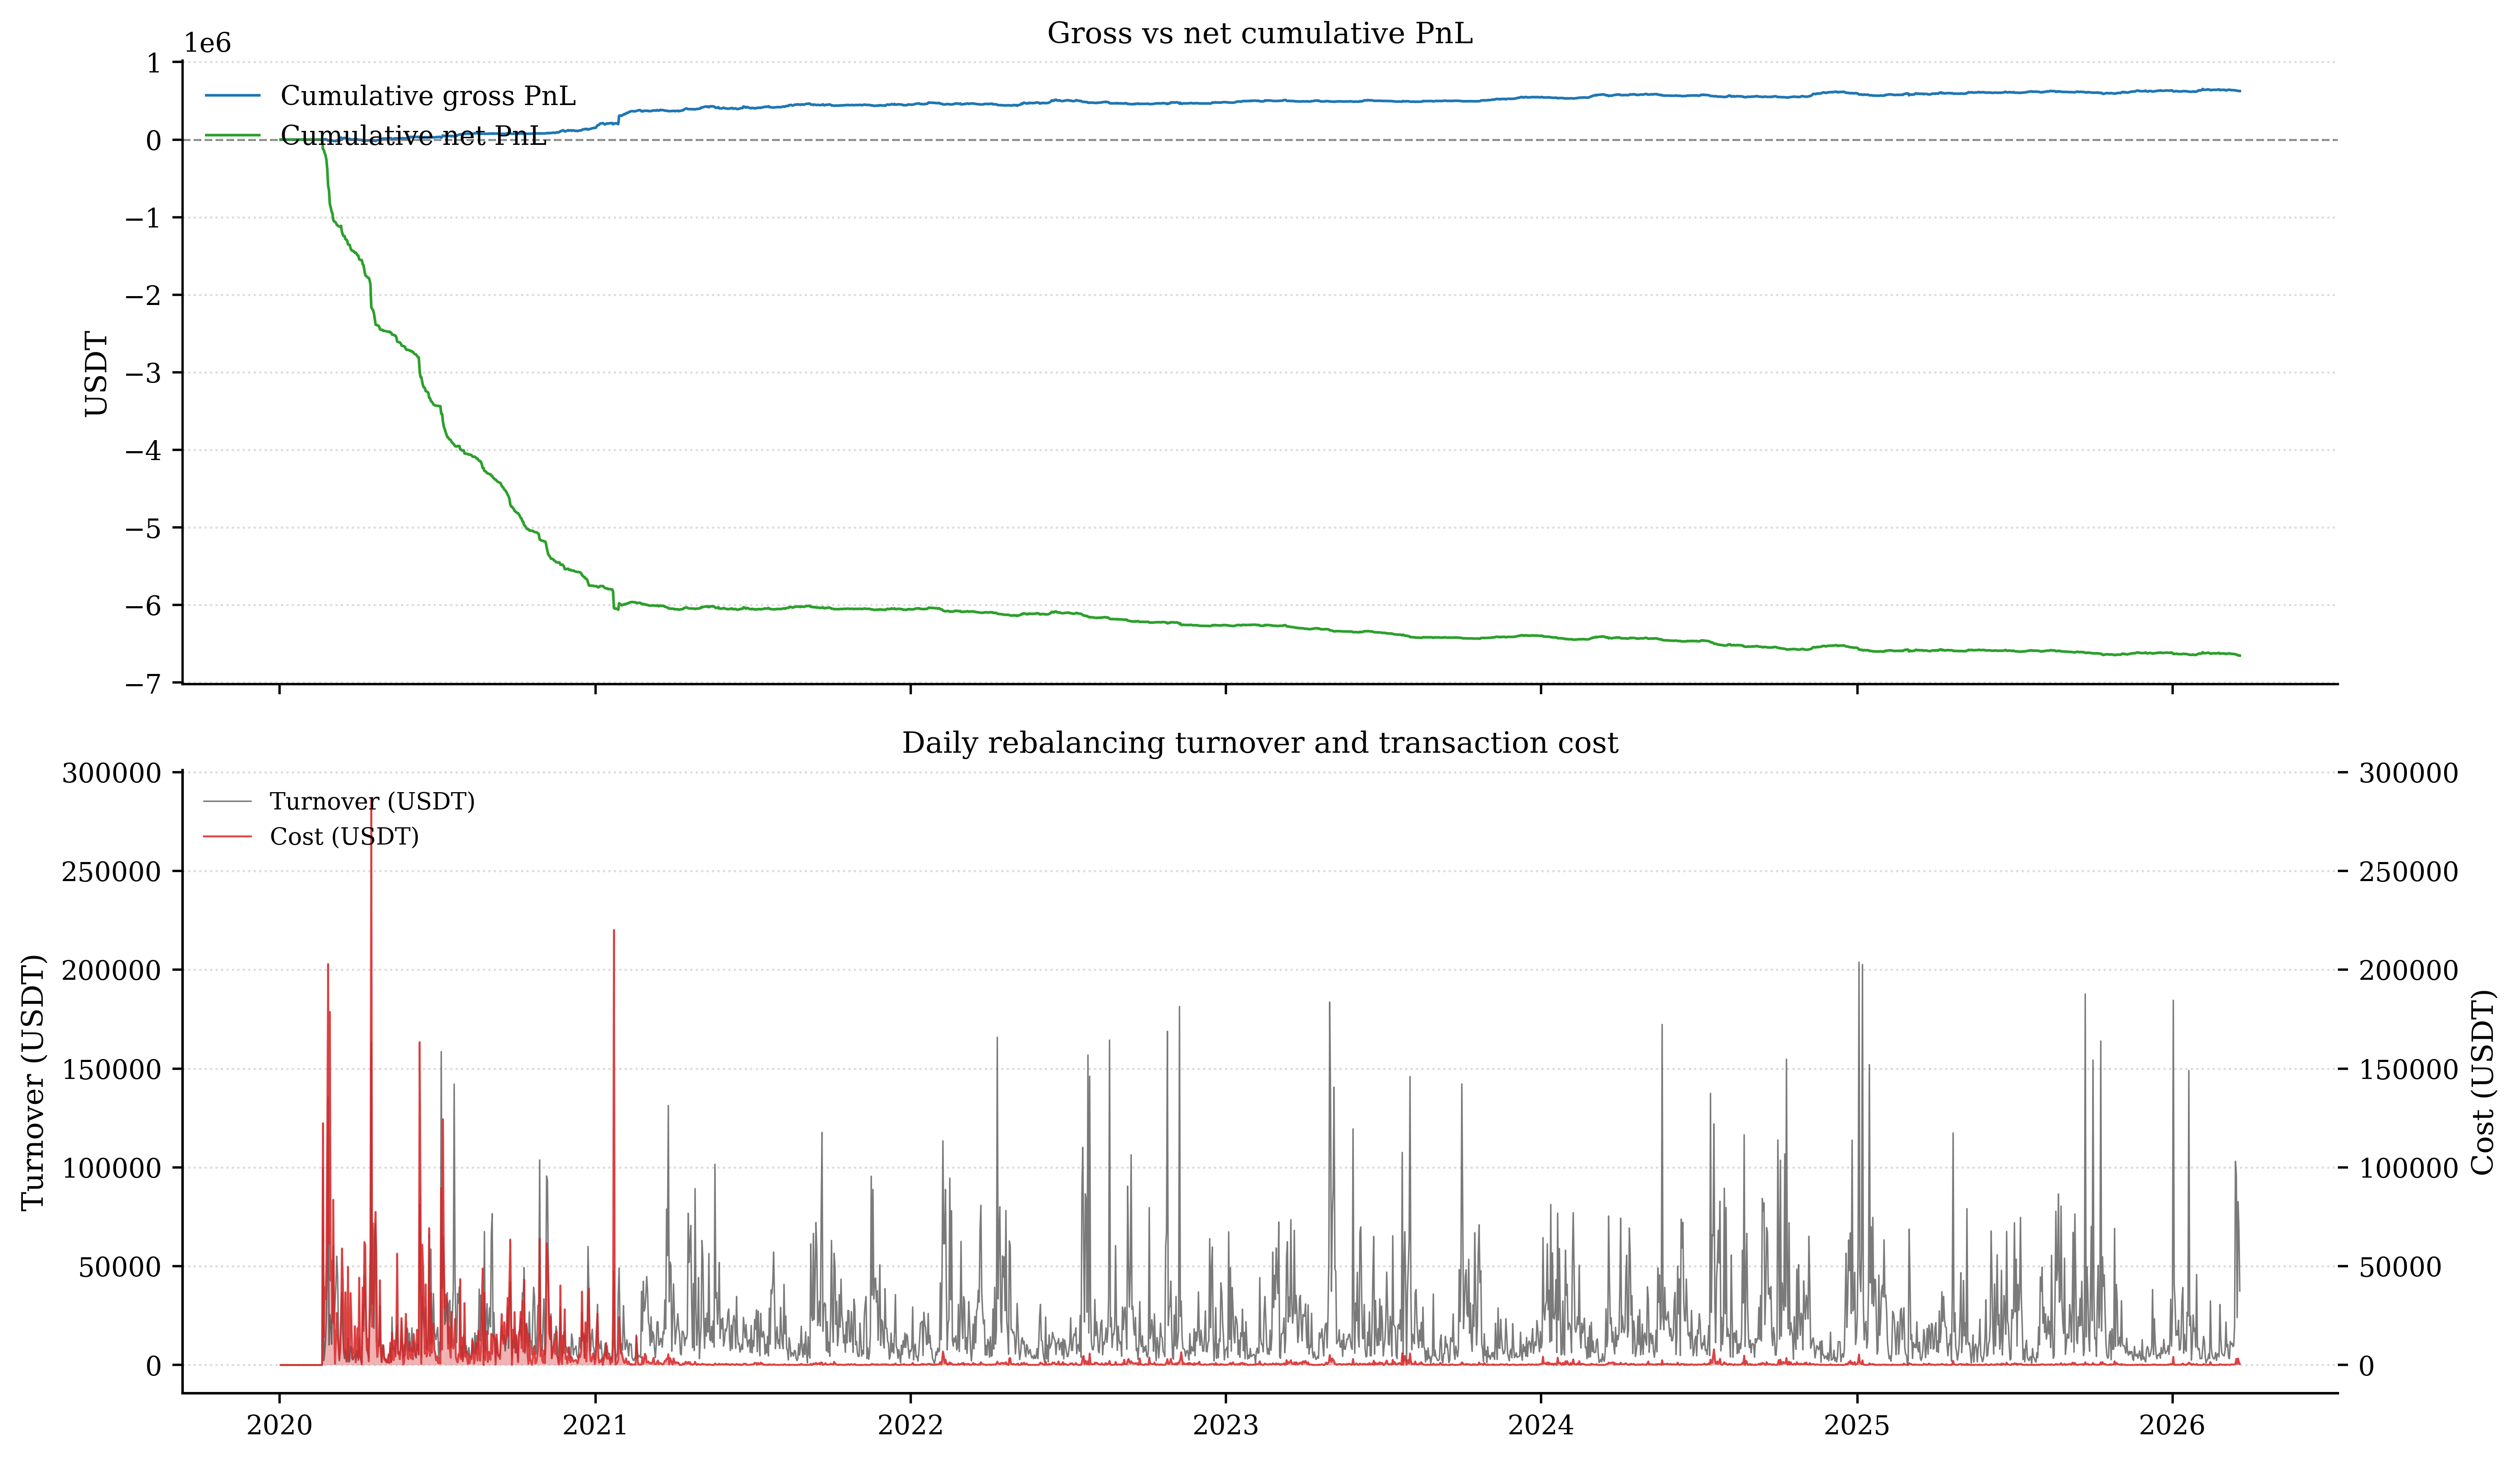

In [12]:
# --- Abdi–Ranaldo spread (same implementation as strategy_final.ipynb) ---


def abdi_ranaldo_spread(frame: pd.DataFrame, window: int = 21) -> pd.Series:
    cols = {col.lower(): col for col in frame.columns}
    required = {"high", "low", "close"}
    missing = required.difference(cols)
    if missing:
        raise KeyError(f"Missing required columns: {sorted(missing)}")

    high = pd.to_numeric(frame[cols["high"]], errors="coerce")
    low = pd.to_numeric(frame[cols["low"]], errors="coerce")
    close = pd.to_numeric(frame[cols["close"]], errors="coerce")

    log_high = np.log(high.where(high > 0))
    log_low = np.log(low.where(low > 0))
    log_close = np.log(close.where(close > 0))

    midpoint = (log_high + log_low) / 2.0
    s2 = 4.0 * (log_close.shift(1) - midpoint.shift(1)) * (log_close.shift(1) - midpoint)
    spread = np.sqrt(s2.rolling(window=window, min_periods=window).mean().abs())
    return spread.replace([np.inf, -np.inf], np.nan).rename("abdi_ranaldo_spread")


ar_by_asset = {}
for s in SYMBOLS:
    ar_by_asset[s] = abdi_ranaldo_spread(cleaned_frames[s]).reindex(asset_panel.index)

ar_spread_wide = pd.concat([ar_by_asset[s] for s in SYMBOLS], axis=1, keys=SYMBOLS)
close_px = asset_panel["close"]

# Half-spread fraction (lagged): cost per USDT traded in that name
half_spread = 0.5 * ar_spread_wide
half_spread_frac = half_spread.shift(1).divide(close_px.shift(1)).replace([np.inf, -np.inf], np.nan)

# Coursework turnover: |theta_t - theta_{t-1}(1+r_{t-1})|
theta_tgt = exposure_panel["theta"]
theta_prev = theta_tgt.shift(1)
r_lag = r.shift(1)
carried = theta_prev * (1.0 + r_lag)
delta_theta = theta_tgt - carried
turnover = delta_theta.abs().sum(axis=1)
cost_t = (delta_theta.abs() * half_spread_frac).sum(axis=1).fillna(0.0)

net_pnl = gross_pnl - cost_t
cumulative_net_pnl = net_pnl.cumsum()
net_portfolio_value = V0 + cumulative_net_pnl

net_backtest_summary = pd.DataFrame(
    {
        "gross_pnl": gross_pnl,
        "cost": cost_t,
        "net_pnl": net_pnl,
        "cumulative_net_pnl": cumulative_net_pnl,
        "net_portfolio_value": net_portfolio_value,
        "turnover": turnover,
    }
)

print(f"Total gross PnL (USDT): {cumulative_gross_pnl.iloc[-1]:,.2f}")
print(f"Total costs (USDT):     {cost_t.sum():,.2f}")
print(f"Total net PnL (USDT):   {cumulative_net_pnl.iloc[-1]:,.2f}")
display(net_backtest_summary.head())

# --- Net vs gross + cost + turnover (saved figures) ---
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(net_backtest_summary.index, cumulative_gross_pnl, color="tab:blue", linewidth=0.9, label="Cumulative gross PnL")
axes[0].plot(net_backtest_summary.index, cumulative_net_pnl, color="tab:green", linewidth=0.9, label="Cumulative net PnL")
axes[0].axhline(0.0, color="0.4", linewidth=0.7, linestyle="--", alpha=0.7)
axes[0].set_ylabel("USDT")
axes[0].legend(loc="upper left", frameon=False)
axes[0].set_title("Gross vs net cumulative PnL")
axes[0].grid(True, axis="y", linestyle=":", linewidth=0.7, alpha=0.45)

axes[1].fill_between(net_backtest_summary.index, 0.0, cost_t, step="mid", color="tab:red", alpha=0.35, linewidth=0)
axes[1].plot(net_backtest_summary.index, turnover, color="0.2", linewidth=0.5, alpha=0.65, label="Turnover (USDT)")
ax_r = axes[1].twinx()
ax_r.plot(net_backtest_summary.index, cost_t, color="tab:red", linewidth=0.65, alpha=0.85, label="Cost (USDT)")
axes[1].set_ylabel("Turnover (USDT)")
ax_r.set_ylabel("Cost (USDT)")
axes[1].set_title("Daily rebalancing turnover and transaction cost")
lines, labels = axes[1].get_legend_handles_labels()
lines2, labels2 = ax_r.get_legend_handles_labels()
ax_r.legend(lines + lines2, labels + labels2, loc="upper left", frameon=False, fontsize=8)
axes[1].grid(True, axis="y", linestyle=":", linewidth=0.7, alpha=0.45)
for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
out_dir = Path("output")
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / "net_vs_gross_cost_turnover.png", bbox_inches="tight", dpi=150)
fig.savefig(out_dir / "net_vs_gross_cost_turnover.pdf", bbox_inches="tight")
plt.show()

### Strategy 1 – Performance metrics and IS / OOS reporting

**Returns:** daily **net equity return** \(r_t = V_t / V_{t-1} - 1\) from **`net_portfolio_value`** (alternatively `net_pnl_t / V_{t-1}\); document if you switch).

**Ratios (annualised, \(\sqrt{252}\)):** **Sharpe** (full-sample std), **Sortino** (downside deviation vs 0), **Calmar** (annualised net return / |max drawdown| on net equity).

**Risk:** **max drawdown** on **`net_portfolio_value`**.

**Holding horizon:** mean length of **contiguous** days with **any** executed exposure (`\(\sum_i |\theta_{i,t-1}| > 0\)`).

**IS / OOS:** **in-sample** = dates in **`dev_index`**; **out-of-sample** = **`holdout_index`** (same split as walk-forward). Metrics computed on each subsample’s **aligned** returns and equity path.

In [13]:
# --- Performance metrics (net) + IS / OOS ---
TRADING_DAYS = 252

r_net_daily = net_portfolio_value.pct_change().replace([np.inf, -np.inf], np.nan)


def max_dd(equity: pd.Series) -> float:
    eq = equity.dropna()
    if eq.empty:
        return np.nan
    peak = eq.cummax()
    dd = (eq - peak) / peak.replace(0.0, np.nan)
    return float(dd.min())


def sharpe_ratio(returns: pd.Series) -> float:
    r = returns.dropna()
    if len(r) < 2 or r.std(ddof=1) == 0:
        return np.nan
    return float(np.sqrt(TRADING_DAYS) * r.mean() / r.std(ddof=1))


def sortino_ratio(returns: pd.Series, mar: float = 0.0) -> float:
    r = returns.dropna()
    downside = r[r < mar] - mar
    if len(r) < 2 or len(downside) == 0:
        return np.nan
    ds = downside.std(ddof=0)
    if ds == 0 or np.isnan(ds):
        return np.nan
    return float(np.sqrt(TRADING_DAYS) * (r.mean() - mar) / ds)


def calmar_ratio(returns: pd.Series, equity: pd.Series) -> float:
    r = returns.dropna()
    if len(r) < 2:
        return np.nan
    ann = (1.0 + r.mean()) ** TRADING_DAYS - 1.0
    mdd = max_dd(equity)
    if mdd is None or mdd == 0 or np.isnan(mdd):
        return np.nan
    return float(ann / abs(mdd))


def mean_holding_horizon(exec_theta: pd.DataFrame) -> float:
    active = exec_theta.fillna(0.0).abs().sum(axis=1) > 0
    if not active.any():
        return np.nan
    grp = (active != active.shift(fill_value=False)).cumsum()
    run_lens = active.groupby(grp).sum()
    run_lens = run_lens[run_lens > 0]
    return float(run_lens.mean()) if len(run_lens) else np.nan


def perf_block(mask: pd.Index, label: str) -> dict:
    m = net_portfolio_value.index.isin(mask)
    eq = net_portfolio_value[m]
    r = r_net_daily[m]
    total_ret = float(eq.iloc[-1] / eq.iloc[0] - 1.0) if len(eq) > 1 else np.nan
    ann_ret = float((1.0 + r.mean()) ** TRADING_DAYS - 1.0) if len(r.dropna()) > 1 else np.nan
    return {
        "sample": label,
        "n_days": int(m.sum()),
        "total_return": total_ret,
        "ann_return": ann_ret,
        "sharpe": sharpe_ratio(r),
        "sortino": sortino_ratio(r),
        "calmar": calmar_ratio(r, eq),
        "max_drawdown": max_dd(eq),
        "total_net_pnl": float(net_pnl.loc[m].sum()) if m.any() else np.nan,
    }


horizon_days = mean_holding_horizon(theta_exec)

perf_full = {
    "sample": "full",
    "n_days": len(net_portfolio_value),
    "total_return": float(net_portfolio_value.iloc[-1] / V0 - 1.0),
    "ann_return": float((1.0 + r_net_daily.mean()) ** TRADING_DAYS - 1.0),
    "sharpe": sharpe_ratio(r_net_daily),
    "sortino": sortino_ratio(r_net_daily),
    "calmar": calmar_ratio(r_net_daily, net_portfolio_value),
    "max_drawdown": max_dd(net_portfolio_value),
    "total_net_pnl": float(cumulative_net_pnl.iloc[-1]),
    "pct_return_on_V0": float(cumulative_net_pnl.iloc[-1] / V0),
    "mean_holding_horizon_days": horizon_days,
}

perf_is = perf_block(dev_index, "IS (development)")
perf_oos = perf_block(holdout_index, "OOS (holdout)")

perf_df = pd.DataFrame([perf_full, perf_is, perf_oos])

display(perf_df.T)

print(f"Mean holding horizon (days, any nonzero |theta_exec|): {horizon_days:.2f}")

,0,1,2
sample,full,IS (development),OOS (holdout)
n_days,2270,1759,511
total_return,-665.319074,-657.693696,0.01164
ann_return,-0.57894,-0.673275,0.005745
sharpe,-0.21108,-0.240152,0.67793
sortino,-0.132492,-0.144479,1.066157
calmar,-0.00087,-0.001024,NaN
max_drawdown,-665.319074,-657.693696,-0.0
total_net_pnl,-6653190.744425,-6576936.964946,-76253.77948
pct_return_on_V0,-665.319074,NaN,NaN


Mean holding horizon (days, any nonzero |theta_exec|): 2220.00


### Strategy 1 – Walk-forward parameter search (development sample)

We **tune** signal and sizing parameters **only** on the **development** period (`dev_index`), using the **pre-defined walk-forward folds** (`wf_folds`). Each **validation** window is **out-of-sample** relative to the expanding training calendar before it, but **in-sample** relative to the final **holdout** tail (which never enters this grid).

**Grid (illustrative):** `MA_WINDOW` ∈ {50, 75, 100}, `VOL_WINDOW` ∈ {20, 30}, dead-zone threshold ∈ {0.25, 0.5}, **rebalance** every **1** or **3** trading days (forward-filled dollar exposures between rebalance dates).

**Per fold** on **net** equity we record validation **Sharpe**, **total return**, **max drawdown**, and **mean turnover**. **Ranking:** primary score = **mean validation Sharpe** minus **`STABILITY_PENALTY ×` std(Sharpe)** across folds (reward stable performance, not a single lucky window).

Implementation uses [`wf_trend_pipeline.py`](wf_trend_pipeline.py) so the pipeline matches the notebook (Abdi–Ranaldo costs, same turnover formula).



In [14]:
from itertools import product
import wf_trend_pipeline as wf

STABILITY_PENALTY = 0.1
SIGNAL_CLIP_WF = 5.0
GROSS_CAP_WF = GROSS_CAP
V0_WF = V0

asset_panel_dev = asset_panel.loc[dev_index].copy()
half_spread_frac_dev = wf.compute_half_spread_frac(asset_panel_dev, cleaned_frames, SYMBOLS)

MA_GRID = [50, 75, 100]
VOL_GRID = [20, 30]
THRESH_GRID = [0.25, 0.5]
REBAL_GRID = [1, 3]

wf_rows = []
for ma_w, vol_w, dz, rebal in product(MA_GRID, VOL_GRID, THRESH_GRID, REBAL_GRID):
    theta_p = wf.build_signal_and_theta(
        asset_panel_dev,
        SYMBOLS,
        ma_window=ma_w,
        vol_window=vol_w,
        dead_zone=dz,
        signal_clip=SIGNAL_CLIP_WF,
        gross_cap=GROSS_CAP_WF,
        rebalance_every=rebal,
    )
    out_p = wf.run_net_backtest(
        asset_panel_dev,
        theta_p,
        SYMBOLS,
        half_spread_frac_dev,
        backtest_use_excess=BACKTEST_USE_EXCESS,
        v0=V0_WF,
    )
    net_pv = out_p["net_portfolio_value"]
    turn = out_p["turnover"]
    fold_sharpes = []
    fold_rets = []
    fold_dds = []
    fold_tos = []
    for _, row in wf_folds.iterrows():
        val_ix = dev_index[(dev_index >= row["val_start"]) & (dev_index <= row["val_end"])]
        m = wf.metrics_on_window(net_pv, turn, val_ix)
        fold_sharpes.append(m["sharpe"])
        fold_rets.append(m["total_return"])
        fold_dds.append(m["max_dd"])
        fold_tos.append(m["mean_turnover"])
    fs = np.array(fold_sharpes, dtype=float)
    mean_s = float(np.nanmean(fs))
    std_s = float(np.nanstd(fs, ddof=1)) if np.sum(np.isfinite(fs)) > 1 else 0.0
    score = mean_s - STABILITY_PENALTY * std_s
    wf_rows.append(
        {
            "MA_WINDOW": ma_w,
            "VOL_WINDOW": vol_w,
            "DEAD_ZONE": dz,
            "rebalance_every": rebal,
            "mean_val_sharpe": mean_s,
            "std_val_sharpe": std_s,
            "wf_score": score,
            "mean_val_return": float(np.nanmean(fold_rets)),
            "mean_val_max_dd": float(np.nanmean(fold_dds)),
            "mean_val_turnover": float(np.nanmean(fold_tos)),
        }
    )

wf_search_df = pd.DataFrame(wf_rows).sort_values("wf_score", ascending=False).reset_index(drop=True)
display(wf_search_df.head(15))

best = wf_search_df.iloc[0]
WF_BEST_MA = int(best["MA_WINDOW"])
WF_BEST_VOL = int(best["VOL_WINDOW"])
WF_BEST_DZ = float(best["DEAD_ZONE"])
WF_BEST_REBAL = int(best["rebalance_every"])
print(
    f"Chosen (WF): MA={WF_BEST_MA}, VOL={WF_BEST_VOL}, DEAD_ZONE={WF_BEST_DZ}, rebalance_every={WF_BEST_REBAL} | "
    f"mean val Sharpe={best['mean_val_sharpe']:.4f}, score={best['wf_score']:.4f}"
)



,MA_WINDOW,VOL_WINDOW,DEAD_ZONE,rebalance_every,mean_val_sharpe,std_val_sharpe,wf_score,mean_val_return,mean_val_max_dd,mean_val_turnover
0,75,20,0.50,1,2.875861,1.636012,2.712260,0.013640,0.0,20316.029333
1,75,20,0.25,1,2.767984,1.684255,2.599558,0.013751,0.0,19579.969753
2,75,30,0.50,1,2.757314,1.669887,2.590326,0.014958,0.0,19840.394898
3,75,30,0.25,1,2.708636,1.723607,2.536275,0.015242,0.0,19126.010251
4,100,30,0.50,1,2.583509,1.758794,2.407629,0.019131,0.0,17238.124250
5,100,20,0.50,1,2.568388,1.703579,2.398030,0.016591,0.0,17498.227609
6,100,30,0.25,1,2.540778,1.793134,2.361465,0.018940,0.0,16809.979989
7,100,20,0.25,1,2.507103,1.740666,2.333036,0.016284,0.0,17017.270712
8,50,20,0.50,1,2.492105,1.774443,2.314661,0.008887,0.0,22802.547784
9,50,30,0.50,1,2.465081,1.836730,2.281408,0.009708,0.0,22437.008157


Chosen (WF): MA=75, VOL=20, DEAD_ZONE=0.5, rebalance_every=1 | mean val Sharpe=2.8759, score=2.7123


### Strategy 1 – Final holdout (untouched OOS)

Parameters are **frozen** to the walk-forward winner above. The strategy is re-estimated on the **full** sample index so rolling windows are **causal** up to each holdout date, but **metrics are reported only** on **`holdout_index`** (no parameter refitting on that segment).



In [16]:
# --- Frozen parameters: single run, metrics on holdout only ---
half_spread_frac_full = wf.compute_half_spread_frac(asset_panel, cleaned_frames, SYMBOLS)

theta_holdout_run = wf.build_signal_and_theta(
    asset_panel,
    SYMBOLS,
    ma_window=WF_BEST_MA,
    vol_window=WF_BEST_VOL,
    dead_zone=WF_BEST_DZ,
    signal_clip=SIGNAL_CLIP_WF,
    gross_cap=GROSS_CAP_WF,
    rebalance_every=WF_BEST_REBAL,
)
out_hold = wf.run_net_backtest(
    asset_panel,
    theta_holdout_run,
    SYMBOLS,
    half_spread_frac_full,
    backtest_use_excess=BACKTEST_USE_EXCESS,
    v0=V0_WF,
)

net_pv_h = out_hold["net_portfolio_value"]
turn_h = out_hold["turnover"]
net_pnl_h = out_hold["net_pnl"]

eq_oos = net_pv_h.reindex(holdout_index).dropna()
r_oos = eq_oos.pct_change().dropna()

TRADING_DAYS = 252


def _sortino(rs: pd.Series, mar: float = 0.0) -> float:
    downside = rs[rs < mar] - mar
    if len(rs) < 2 or len(downside) == 0:
        return np.nan
    ds = downside.std(ddof=0)
    if ds == 0 or np.isnan(ds):
        return np.nan
    return float(np.sqrt(TRADING_DAYS) * (rs.mean() - mar) / ds)


def _calmar(eq: pd.Series) -> float:
    r = eq.pct_change().dropna()
    if len(r) < 2:
        return np.nan
    ann = float((1.0 + r.mean()) ** TRADING_DAYS - 1.0)
    mdd = wf.max_drawdown(eq)
    if mdd is None or mdd == 0 or np.isnan(mdd):
        return np.nan
    return float(ann / abs(mdd))


holdout_metrics = {
    "n_days": len(eq_oos),
    "sharpe": wf.sharpe_ratio(r_oos, TRADING_DAYS),
    "sortino": _sortino(r_oos),
    "calmar": _calmar(eq_oos),
    "max_drawdown": wf.max_drawdown(eq_oos),
    "mean_turnover": float(turn_h.reindex(holdout_index).mean()),
    "total_net_pnl": float(net_pnl_h.reindex(holdout_index).sum()),
    "pct_return_on_V0": float(net_pnl_h.reindex(holdout_index).sum() / V0_WF),
    "final_net_equity": float(eq_oos.iloc[-1]) if len(eq_oos) else np.nan,
}

holdout_metrics_df = pd.DataFrame([holdout_metrics], index=["Holdout (final OOS)"])
display(holdout_metrics_df.T)
print("Holdout period:", holdout_index.min(), "→", holdout_index.max())



,Holdout (final OOS)
n_days,5.110000e+02
sharpe,1.498732e-01
sortino,2.250761e-01
calmar,NaN
max_drawdown,-0.000000e+00
mean_turnover,1.733501e+04
total_net_pnl,-1.563064e+04
pct_return_on_V0,-1.563064e+00
final_net_equity,-5.158362e+06


Holdout period: 2024-10-26 00:00:00+00:00 → 2026-03-20 00:00:00+00:00
